<a href="https://colab.research.google.com/github/sruthis1606/mall-CSV/blob/main/Mall_Customers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
df = pd.read_csv("Mall_Customers.csv")

print("Original Dataset:")
print(df.head())

Original Dataset:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [ ]:
print("\nFirst 5 Records:")
print(df.head())


First 5 Records:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [ ]:
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(200, 5)


In [ ]:
print("\nData Types:")
print(df.dtypes)


Data Types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [ ]:
if "CustomerID" in df.columns:
    df = df.drop("CustomerID", axis=1)

In [ ]:
df["Gender"] = df["Gender"].map({
    "Male": 0,
    "Female": 1
})


print("\nAfter Gender Conversion:")
print(df.head())


After Gender Conversion:
   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0       0   19                  15                      39
1       0   21                  15                      81
2       1   20                  16                       6
3       1   23                  16                      77
4       1   31                  17                      40


In [ ]:
X = df[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]


print("\nSelected Features:")
print(X.head())


Selected Features:
   Age  Annual Income (k$)  Spending Score (1-100)
0   19                  15                      39
1   21                  15                      81
2   20                  16                       6
3   23                  16                      77
4   31                  17                      40


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nStandardized Data:")
print(X_scaled[:5])


Standardized Data:
[[-1.42456879 -1.73899919 -0.43480148]
 [-1.28103541 -1.73899919  1.19570407]
 [-1.3528021  -1.70082976 -1.71591298]
 [-1.13750203 -1.70082976  1.04041783]
 [-0.56336851 -1.66266033 -0.39597992]]


In [ ]:
linkage_matrix = linkage(
    X_scaled,
    method="ward"
)


print("\nLinkage Matrix:")
print(linkage_matrix[:5])


Linkage Matrix:
[[6.50000000e+01 6.80000000e+01 7.17666897e-02 2.00000000e+00]
 [1.29000000e+02 1.31000000e+02 7.17666897e-02 2.00000000e+00]
 [1.06000000e+02 1.09000000e+02 7.76431214e-02 2.00000000e+00]
 [3.00000000e+00 5.00000000e+00 9.00803899e-02 2.00000000e+00]
 [9.20000000e+01 9.60000000e+01 1.05730374e-01 2.00000000e+00]]


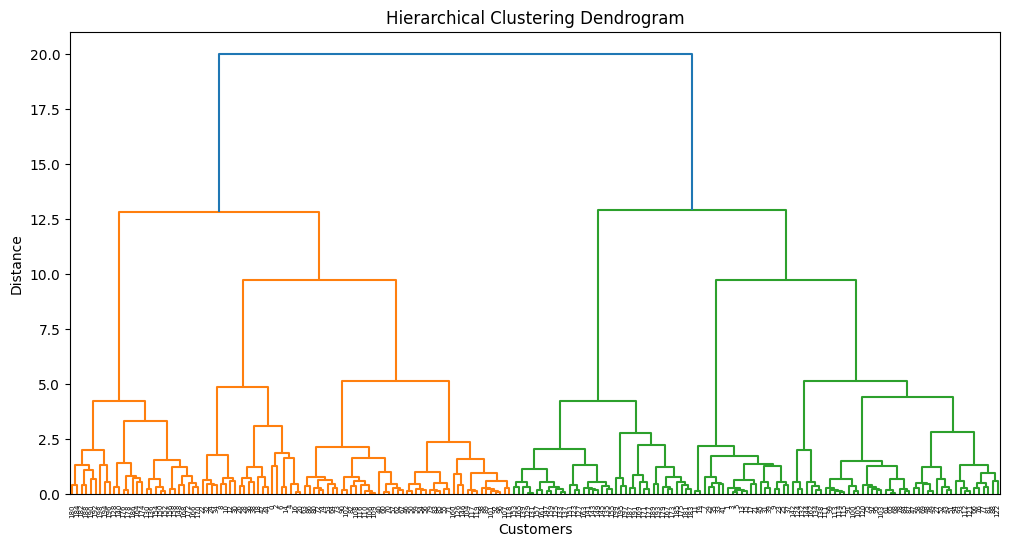

In [ ]:
plt.figure(figsize=(12, 6))

dendrogram(linkage_matrix)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()



In [ ]:
model = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

In [ ]:
labels = model.fit_predict(X_scaled)


# Add cluster labels to original dataset
df["Cluster"] = labels


print("\nCluster Labels:")
print(labels)


print("\nFinal Customer Segmentation:")
print(df.head(20))


Cluster Labels:
[4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4
 0 4 0 1 0 4 0 4 0 1 0 0 0 1 0 0 1 1 1 1 1 0 1 1 0 1 1 1 0 0 1 0 0 1 1 1 1
 1 0 0 0 0 1 1 0 1 1 0 1 1 0 0 1 1 0 1 0 0 0 1 0 1 0 0 1 1 0 1 0 1 1 1 1 1
 0 0 0 0 0 1 1 1 1 0 0 0 2 0 2 1 2 3 2 3 2 0 2 0 2 3 2 0 2 3 2 0 2 0 2 1 2
 3 2 3 2 3 2 3 2 3 2 3 2 1 2 0 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3
 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2]

Final Customer Segmentation:
    Gender  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0        0   19                  15                      39        4
1        0   21                  15                      81        0
2        1   20                  16                       6        4
3        1   23                  16                      77        0
4        1   31                  17                      40        4
5        1   22                  17                      76        0
6        1   35                  18                       6    